In [1]:
from typing import cast

from datasets import Dataset
from datasets import load_dataset as hf_load

# Download MNIST test split (10 000 images of 28×28 handwritten digits)
mnist_test = cast(Dataset, hf_load("ylecun/mnist", split="test"))

/home/aweng/2033/dataeval-flow/.nox/docs/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from pathlib import Path

from PIL import Image

data_dir = Path("./data/drift_tutorial")

ref_dir = data_dir / "reference"
ref_dir.mkdir(parents=True, exist_ok=True)

# Use the first 2000 images as reference — flat directory, no class subdirs
for i in range(2000):
    sample = mnist_test[i]
    img: Image.Image = sample["image"]  # type: ignore[index]
    img.save(ref_dir / f"{i:05d}.png")

print(f"Reference: 2000 images saved to {ref_dir}")

Reference: 2000 images saved to data/drift_tutorial/reference


In [3]:
from PIL import ImageFilter

incoming_dir = data_dir / "incoming"
incoming_dir.mkdir(parents=True, exist_ok=True)

n_incoming = 1000
n_clean = 500  # first half: clean
blur_radius = 1.5  # gentle blur — digits become perceptibly softer

for j in range(n_incoming):
    idx = 2000 + j  # use different images than reference
    sample = mnist_test[idx]
    img = sample["image"]

    # Apply blur to the second half (indices 500–999)
    if j >= n_clean:
        img = img.filter(ImageFilter.GaussianBlur(radius=blur_radius))

    # Flat directory with sequential names — preserves temporal order
    img.save(incoming_dir / f"{j:05d}.png")

print(f"Incoming: {n_incoming} images saved to {incoming_dir}")
print(f"  Clean (first {n_clean}): unmodified digits")
print(f"  Blurred (last {n_incoming - n_clean}): Gaussian blur radius={blur_radius}")

Incoming: 1000 images saved to data/drift_tutorial/incoming
  Clean (first 500): unmodified digits
  Blurred (last 500): Gaussian blur radius=1.5


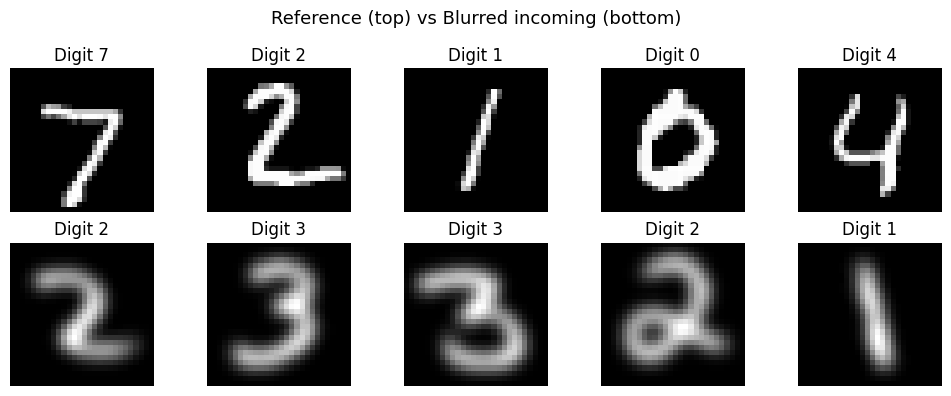

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for row in range(2):
    for col in range(5):
        sample = mnist_test[(2500 if row else 0) + col]
        img = sample["image"].filter(ImageFilter.GaussianBlur(radius=blur_radius)) if row else sample["image"]
        axes[row, col].imshow(img, cmap="gray")  # type: ignore[index]
        axes[row, col].set_title(f"Digit {sample['label']}")  # type: ignore[index]
        axes[row, col].axis("off")

fig.suptitle("Reference (top) vs Blurred incoming (bottom)", fontsize=13)
plt.tight_layout()
plt.show()

In [5]:
from dataeval_flow.config import FlattenExtractorConfig, ImageFolderDatasetConfig, PipelineConfig, SourceConfig

# --- Datasets ---
# First dataset = reference, second = incoming test data
# Flat image folders (no class subdirs) — preserves temporal ordering
ref_dataset = ImageFolderDatasetConfig(
    name="reference",
    path=str(ref_dir),
)

incoming_dataset = ImageFolderDatasetConfig(
    name="incoming",
    path=str(incoming_dir),
)

# --- Extractor ---
# Flatten reshapes each 28×28 grayscale image into a 784-D feature vector — no model file needed
extractor_config = FlattenExtractorConfig(name="flatten", batch_size=64)

In [6]:
from dataeval_flow.config import DriftMonitoringTaskConfig, DriftMonitoringWorkflowConfig
from dataeval_flow.workflow import run_task
from dataeval_flow.workflows.drift.params import (
    ChunkingConfig,
    DriftDetectorKNeighbors,
    DriftDetectorMMD,
    DriftDetectorUnivariate,
    DriftHealthThresholds,
)

# --- Drift workflow ---
# Chunking is configured per detector — K-Neighbors and MMD get chunked,
# while the univariate CVM detector runs a single overall test.
drift_overall = DriftMonitoringTaskConfig(
    name="mnist-drift-overall",
    workflow="mnist-drift",
    sources=["ref_src", "inc_src"],
    extractor="flatten",
)

config = PipelineConfig(
    datasets=[ref_dataset, incoming_dataset],
    sources=[
        SourceConfig(name="ref_src", dataset="reference"),
        SourceConfig(name="inc_src", dataset="incoming"),
    ],
    extractors=[extractor_config],
    workflows=[
        DriftMonitoringWorkflowConfig(
            name="mnist-drift",
            detectors=[
                DriftDetectorKNeighbors(k=10, chunking=ChunkingConfig(chunk_size=200, threshold_multiplier=4.0)),
                DriftDetectorMMD(n_permutations=100, chunking=ChunkingConfig(chunk_size=200, threshold_multiplier=4.0)),
                DriftDetectorUnivariate(test="cvm"),  # non-chunked overall test
            ],
            health_thresholds=DriftHealthThresholds(
                chunk_drift_pct_warning=15.0,  # warn if >15% of chunks drift
                consecutive_chunks_warning=2,  # warn on 2+ consecutive drifted chunks
            ),
        ),
    ],
    tasks=[drift_overall],
)

In [7]:
result = run_task(drift_overall, config, cache_dir=Path("./cache"))

In [8]:
print(result.report())


  DRIFT MONITORING COMPLETE. REFERENCE: 2000 ITEMS, TEST: 1000 ITEMS.
  Timestamp:    2026-06-09T17:45:54.470169+00:00
  Duration:     2.32s
  Source:       ref_src (reference)
                inc_src (incoming)
  Model:        flatten (flatten)
--------------------------------------------------------------------------------

  SUMMARY
  -------
  K-Neighbors (chunk_size=200, z=4.0) .................................   [!!]
  MMD (chunk_size=200, z=4.0) .........................................   [!!]
  CVM Univariate ......................................................   [!!]

  Health: 3 warning(s) [!!] — review flagged findings

  K-NEIGHBORS (CHUNK_SIZE=200, Z=4.0)
  3/5 chunks drifted (60%) | max consecutive: 3

  Chunk       Distance                                  Status
  ---------  ---------  ------------------------------  ------
  [0:199]    2715.9509  █████████████████████████████░  ok
  [200:399]  2651.7363  ████████████████████████████░░  ok
  [400:599]  2490.7148  ███

In [9]:
import polars as pl

pl.Config.set_tbl_hide_dataframe_shape(True)

raw = result.data.raw
print(f"Reference size: {raw.reference_size}")
print(f"Test size:      {raw.test_size}")
print()

for method, det_result in raw.detectors.items():
    print(f"── {method} ({det_result['metric_name']}) ──")
    print(f"  Overall drifted: {det_result['drifted']}")
    print(f"  Distance:        {det_result['distance']:.6g}")

    chunks = det_result.get("chunks", [])
    if chunks:
        df = pl.DataFrame(chunks).select("key", "value", "lower_threshold", "upper_threshold", "drifted")
        print(df)
    print()

Reference size: 2000
Test size:      1000

── kneighbors (knn_distance) ──
  Overall drifted: True
  Distance:        2504.11
┌───────────┬─────────────┬─────────────────┬─────────────────┬─────────┐
│ key       ┆ value       ┆ lower_threshold ┆ upper_threshold ┆ drifted │
│ ---       ┆ ---         ┆ ---             ┆ ---             ┆ ---     │
│ str       ┆ f64         ┆ f64             ┆ f64             ┆ bool    │
╞═══════════╪═════════════╪═════════════════╪═════════════════╪═════════╡
│ [0:199]   ┆ 2715.950928 ┆ 2522.541504     ┆ 2776.899902     ┆ false   │
│ [200:399] ┆ 2651.736328 ┆ 2522.541504     ┆ 2776.899902     ┆ false   │
│ [400:599] ┆ 2490.714844 ┆ 2522.541504     ┆ 2776.899902     ┆ true    │
│ [600:799] ┆ 2330.831787 ┆ 2522.541504     ┆ 2776.899902     ┆ true    │
│ [800:999] ┆ 2331.303467 ┆ 2522.541504     ┆ 2776.899902     ┆ true    │
└───────────┴─────────────┴─────────────────┴─────────────────┴─────────┘

── mmd (mmd2) ──
  Overall drifted: True
  Distance:       

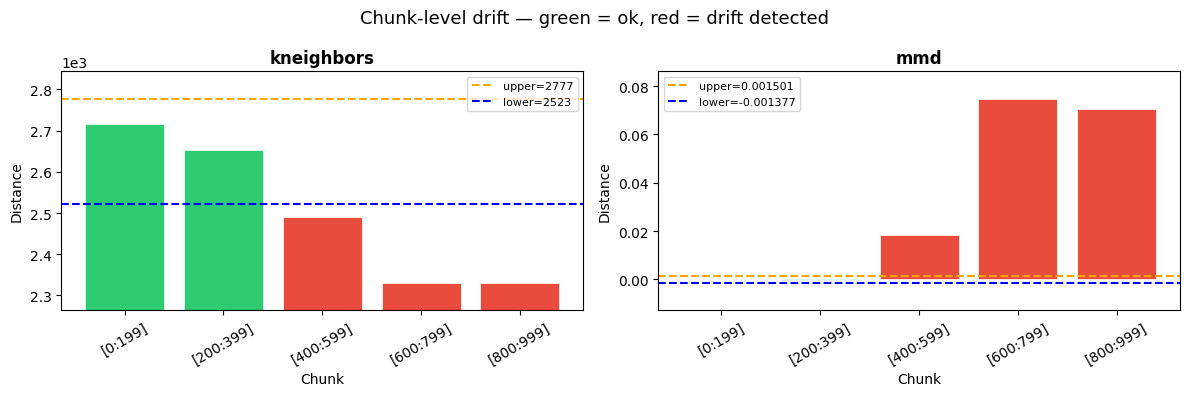

In [10]:
# Only plot detectors that have chunk results
chunked_methods = [m for m, r in raw.detectors.items() if r.get("chunks")]
fig, axes = plt.subplots(1, len(chunked_methods), figsize=(6 * len(chunked_methods), 4))
if len(chunked_methods) == 1:
    axes = [axes]  # type: ignore[list-item]

for ax, method in zip(axes, chunked_methods, strict=True):
    chunks = raw.detectors[method]["chunks"]  # type: ignore[typeddict-item]

    labels = [c["key"] for c in chunks]
    values = [c["value"] for c in chunks]
    colors = ["#e74c3c" if c["drifted"] else "#2ecc71" for c in chunks]

    ax.bar(labels, values, color=colors, edgecolor="white", linewidth=0.5)

    # Draw threshold lines and expand y-axis to include them
    upper_thresh = chunks[0].get("upper_threshold")
    lower_thresh = chunks[0].get("lower_threshold")
    all_y = list(values)
    if upper_thresh is not None:
        ax.axhline(
            y=upper_thresh,
            color="orange",
            linestyle="--",
            linewidth=1.5,
            label=f"upper={upper_thresh:.4g}",
        )
        all_y.append(upper_thresh)
    if lower_thresh is not None:
        ax.axhline(
            y=lower_thresh,
            color="blue",
            linestyle="--",
            linewidth=1.5,
            label=f"lower={lower_thresh:.4g}",
        )
        all_y.append(lower_thresh)
    y_min, y_max = min(all_y), max(all_y)
    margin = (y_max - y_min) * 0.15 or abs(y_max) * 0.1 or 0.01
    ax.set_ylim(y_min - margin, y_max + margin)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(-3, 3))
    ax.legend(fontsize=8)
    ax.set_title(method, fontsize=12, fontweight="bold")
    ax.set_ylabel("Distance")
    ax.set_xlabel("Chunk")
    ax.tick_params(axis="x", rotation=30)

fig.suptitle("Chunk-level drift — green = ok, red = drift detected", fontsize=13)
plt.tight_layout()
plt.show()

In [11]:
json_str = result.export(fmt="json")
print(f"JSON output: {len(json_str)} characters")
print(json_str[:600] + "\n...")

JSON output: 180814 characters
{
  "metadata": {
    "version": "1.0",
    "timestamp": "2026-06-09T17:45:54.470169Z",
    "dataset_id": "reference,incoming",
    "label_source": null,
    "model_id": "flatten (flatten)",
    "preprocessor_id": null,
    "selection_id": null,
    "source_descriptions": [
      "ref_src (reference)",
      "inc_src (incoming)"
    ],
    "resolved_config": {
      "sources": [
        {
          "name": "ref_src",
          "dataset": "reference",
          "dataset_config": {
            "format": "image_folder",
            "name": "reference",
            "path": "data/drift_tutorial/ref
...
